# CFU prediction using TPM values from bulk RNA-seq

## Data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load TPM data and CFU counts.

In [2]:
from src.tpm_data import get_all_tpm_data

# Paths to Fcnts and CFU data
fcnts_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/fcnts_timezero"
cfu_path   = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_cfus"

# Get data
data_df = get_all_tpm_data(
    fcnts_path = fcnts_path,
    cfu_path = cfu_path
)

## Pre-processing

Remove CFU = 0 samples and log-transform CFUs.

In [3]:
# Find idx where CFU = 0, then list the sample ID
zero_idx = np.where(data_df["CFU"] == 0)[0]
print(data_df.index[zero_idx].tolist())

# Check CFU values for the other 2 replicates
rep_names = ["34CEF4hr-a", "34CEF4hr-b"]
cfu_val_check = data_df.loc[rep_names]["CFU"].tolist()
print(f"CFU values for 34CEF4hr-a and 34CEF4hr-b :{cfu_val_check}")

# Remove sample
data_df = data_df[data_df["CFU"] != 0]

# Convert CFU to log 10
data_df["CFU"] = np.log10(data_df["CFU"])

['34CEF4hr-c']
CFU values for 34CEF4hr-a and 34CEF4hr-b :[20000000, 20000000]


## Training with stratified split

PLS regression CV scheme.

In [48]:
from src.split import combination_stratified_split

# Define a function to run nested EN CV
def run_nested_pls_cv(df, splits):

    scores = []

    for train_idx, test_idx in splits:
        train_df = df.iloc[train_idx]
        X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
        y_train = train_df["CFU"]

        test_df = df.iloc[test_idx]
        X_test = test_df.iloc[:, test_df.columns.str.contains("SP")]
        y_test = test_df["CFU"]

        # Create a nested hyperparameter tuning scheme
        param_grid = {
            "model__n_components": list(range(3, 20))
        }
        
        # Make pipeline for PLS regression
        pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", PLSRegression())
        ])

        # Setup GridSearch
        search = GridSearchCV(
            estimator = pipeline,
            cv = 5,
            param_grid = param_grid,
            scoring = "neg_mean_squared_error",
        )

        # Fit with best params
        search.fit(X_train, y_train)
        preds = search.predict(X_test)

        # Evaluate
        score = r2_score(y_test, preds)
        scores.append(score)
    
    mean_score = np.mean(scores)

    # Round
    scores = [round(score, 3) for score in scores]
    mean_score = round(mean_score, 3)

    return scores, mean_score
    
# Make stratified splits
strat_splits = combination_stratified_split(data_df, num_folds = 5, seed = 111)

# Run Nested CV
scores1, mean_score1 = run_nested_pls_cv(
    df = data_df,
    splits = strat_splits
)

print(f"R^2 for 5 folds : {scores1}")
print(f"Mean R^2 : {mean_score1}")

R^2 for 5 folds : [0.845, 0.826, 0.818, 0.863, 0.861]
Mean R^2 : 0.843


## Training with held-out combination(s)

Train on all single-drug data, test on all combination data.

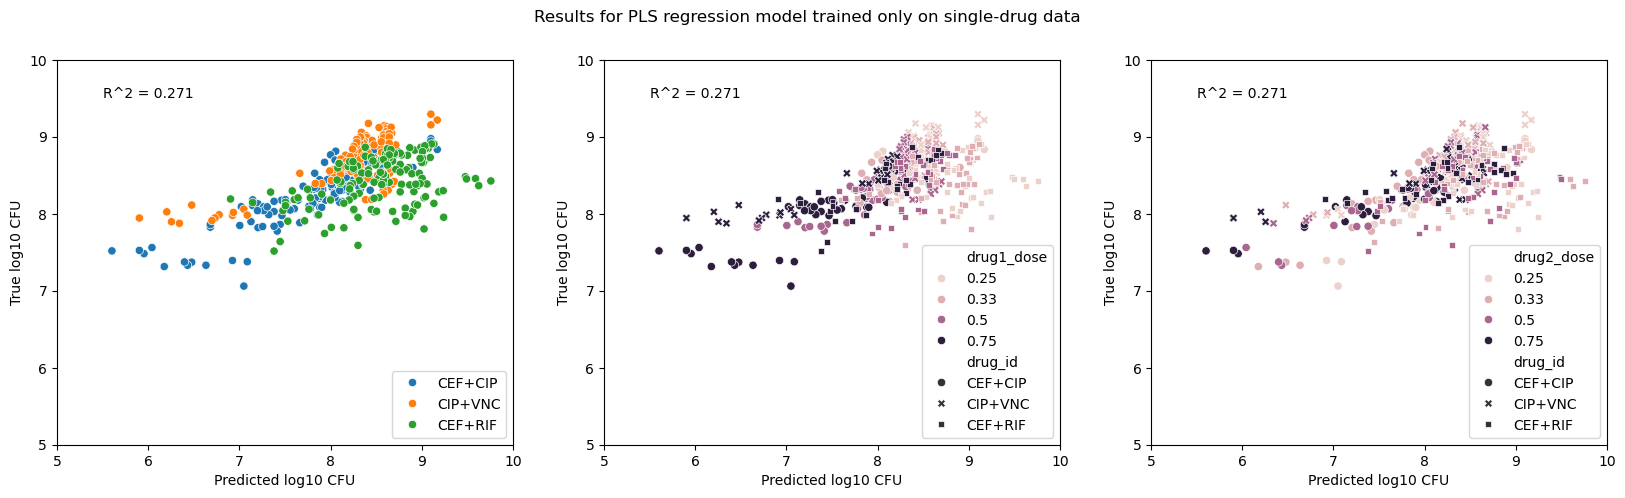

In [29]:
def held_out_combination_eval(df):
    """
    Dataframe must have the metadata attached to it
    """
    single = df[df["num_drugs"] == 1]
    combo = df[df["num_drugs"] == 2]

    # Train test split
    X_train = single.iloc[:, single.columns.str.contains("SP")]
    y_train = single["CFU"]

    X_test = combo.iloc[:, combo.columns.str.contains("SP")]
    y_test = combo["CFU"]
    meta = combo.iloc[:, ~combo.columns.str.contains("SP|CFU")]

    # PLS regression 5-fold CV pipeline
    param_grid = {
        "model__n_components": list(range(3, 20))
    }
    pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
    ])
    search = GridSearchCV(
        estimator = pipeline,
        cv = 5,
        param_grid = param_grid,
        scoring = "neg_mean_squared_error",
    )
    
    # Fit and predict
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)
    score = r2_score(y_test, y_pred)

    # Store results with metadata
    results = meta.copy()
    results["true"] = y_test.to_frame()
    results["pred"] = y_pred

    # Plot
    fig, axes = plt.subplots(1, 3, figsize = (20, 5))

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug_id",
        ax = axes[0]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug1_dose",
        style = "drug_id",
        ax = axes[1]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug2_dose",
        style = "drug_id",
        ax = axes[2]
    )

    # Set axis limits and R^2 annotation
    for ax in axes:
        ax.set_xlim(5, 10)
        ax.set_ylim(5, 10)
        ax.text(5.5, 9.5, f"R^2 = {round(score, 3)}")
        ax.set_ylabel("True log10 CFU")
        ax.set_xlabel("Predicted log10 CFU")
        ax.legend(loc = "lower right")
    
    fig.suptitle("Results for PLS regression model trained only on single-drug data")

held_out_combination_eval(data_df)

## Training with sparse combination matrix

Train on single-drug data and diagonal of combination matrix.

(think about different CV split??)

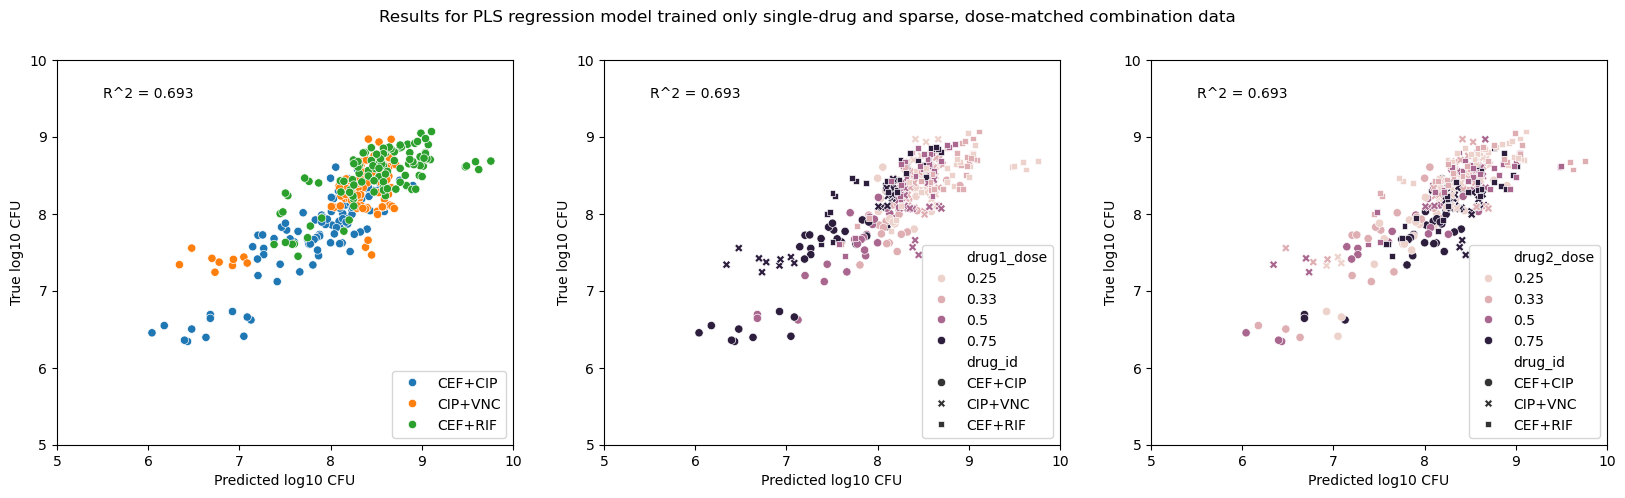

In [32]:
def sparse_diag_eval(df):

    # Mask to get single-drug and sparse matrix data
    mask = (df["num_drugs"] == 1) | ((df["drug1_dose"]) == (df["drug2_dose"]))
    train_df = df[mask]
    test_df = df[~mask]

    # Train-test split
    X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
    y_train = train_df["CFU"]

    X_test = test_df.iloc[:, test_df.columns.str.contains("SP")]
    y_test = test_df["CFU"]
    meta = test_df.iloc[:, ~test_df.columns.str.contains("SP|CFU")]

    # PLS regression CV pipeline
    param_grid = {
        "model__n_components": list(range(3, 20))
    }

    # Make pipeline for PLS regression
    pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
    ])

    # Grid search
    search = GridSearchCV(
        estimator = pipeline,
        cv = 5,
        param_grid = param_grid,
        scoring = "neg_mean_squared_error",
    )

    # Fit with best params
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)

    # Evaluate
    score = r2_score(y_test, y_pred)

    # Store results with metadata
    results = meta.copy()
    results["true"] = y_test.to_frame()
    results["pred"] = y_pred

    # Plot
    fig, axes = plt.subplots(1, 3, figsize = (20, 5))

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug_id",
        ax = axes[0]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug1_dose",
        style = "drug_id",
        ax = axes[1]
    )

    sns.scatterplot(
        results,
        x = "true",
        y = "pred",
        hue = "drug2_dose",
        style = "drug_id",
        ax = axes[2]
    )

    # Set axis limits and R^2 annotation
    for ax in axes:
        ax.set_xlim(5, 10)
        ax.set_ylim(5, 10)
        ax.text(5.5, 9.5, f"R^2 = {round(score, 3)}")
        ax.set_ylabel("True log10 CFU")
        ax.set_xlabel("Predicted log10 CFU")
        ax.legend(loc = "lower right")
    
    fig.suptitle("Results for PLS regression model trained only single-drug and sparse, dose-matched combination data")

sparse_diag_eval(data_df)

## Training with successively more combination data

Implement a gradient of increasing combination data. Add 10 random combination datapoints along x-axis. Each point along the x-axis should contain X different splits, allowing for consistent evaluation. Then, show the mean and std of the R^2 on the y-axis for each datapoint. Look for a plateau of R^2. Then isolate that point and look at mechanistic underpinnings.